# Setup

In [280]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import nbinom, poisson
from scipy.stats import ks_2samp
from scipy.stats import poisson as poisson_dist
import statsmodels.formula.api as smf
import statsmodels.discrete.discrete_model as smd
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import lognorm
from sklearn.model_selection import train_test_split

from EDA import freq_dataset, hazard_datasets_sev

# Frequency Negative Binomial  Model

In [305]:
# Split the data
data_splits_freq = {}

np.random.seed(42)

for name, hazard in freq_dataset.items():
    # Filter null
    data_clean = hazard.dropna(subset=['claim_count'])    
    
    # Shuffle and Split (80% Train, 20% Test)
    train_df, test_df = train_test_split(data_clean, test_size=0.20, random_state=42)
    
    data_splits_freq[name] = {
        'train': train_df,
        'test': test_df
    }

In [306]:
# Define specific drivers for each hazard to avoid noise
hazard_drivers = {
    'Cargo Loss': [
        'cargo_value', 'weight', 'C(cargo_type)', 'route_risk',
        'distance', 'transit_duration', 'pilot_experience',
        'vessel_age', 'C(container_type)', 'solar_radiation',
        'debris_density'
    ],

    'Equipment Failure': [
        'equipment_age', 'maintenance_int', 'usage_int',
        'C(equipment_type)'
    ],

    'Workers Compensation': [
        'occupation', 'employment_type', 'experience_yrs',
        'accident_history_flag', 'psych_stress_index',
        'hours_per_week', 'supervision_level', 'gravity_level',
        'safety_training_index', 'protective_gear_quality',
        'base_salary'
    ],

    'Business Interruptions': [
        'production_load', 'energy_backup_score',
        'supply_chain_index', 'maintenance_freq',
        'avg_crew_exp', 'safety_compliance'
    ]
}

In [307]:
freq_models = {}

for hazard, drivers in hazard_drivers.items():    
    # Filter data for this hazard only
    train_subset = data_splits_freq[hazard]['train']
    train_subset = train_subset[train_subset['exposure'] > 0].copy()
    current_offset = np.log(train_subset['exposure'])

    if hazard != 'Cargo Loss': 
        formula = f"claim_count ~ C(solar_system) + {' + '.join(drivers)}"
    else: 
        formula = f"claim_count ~ {' + '.join(drivers)}"
    
    # Step A: Fit Poisson first to estimate alpha
    poisson = smf.glm(formula=formula, data=train_subset, 
                       family=sm.families.Poisson(), 
                       offset=current_offset).fit()
    
    # Step B: Estimate Alpha for Negative Binomial
    # (Var - Mean) / Mean^2
    mu = train_subset['claim_count'].mean()
    var = train_subset['claim_count'].var()
    est_alpha = max((var - mu) / (mu**2), 0.01) if mu > 0 else 1.0
    
    # Step C: Fit the NB Model
    nb_model = smf.glm(formula=formula, data=train_subset, 
                       family=sm.families.NegativeBinomial(alpha=est_alpha), 
                       offset=current_offset).fit()

    # Store results
    freq_models[hazard] = nb_model
print(freq_models['Cargo Loss'].summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                96933
Model:                            GLM   Df Residuals:                    96913
Model Family:        NegativeBinomial   Df Model:                           19
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -72050.
Date:                Tue, 10 Mar 2026   Deviance:                       81591.
Time:                        19:25:10   Pearson chi2:                 3.00e+05
No. Iterations:                     9   Pseudo R-squ. (CS):           0.001104
Covariance Type:            nonrobust                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

## Validating Model

In [308]:
val_summary = []

for hazard, model in freq_models.items():
    
    # Get hazard-specific test data
    test_df = data_splits_freq[hazard]['test'].copy()
    
    # Keep positive exposure only
    test_df = test_df[test_df['exposure'] > 0].copy()
    
    # Calculate offset
    offset = np.log(test_df['exposure'])
    
    # Predict expected claims
    test_df['expected'] = model.predict(test_df, offset=offset)
    
    # Aggregate validation metrics
    exposure = test_df['exposure'].sum()
    actual = test_df['claim_count'].sum()
    expected = test_df['expected'].sum()
    
    val_summary.append({
        'hazard_type': hazard,
        'Exposure': exposure,
        'Actual': actual,
        'Expected': expected,
        'Actual_Freq': actual / exposure,
        'Expected_Freq': expected / exposure,
        'A/E': actual / expected
    })

val_df = pd.DataFrame(val_summary)

print(val_df[['hazard_type','A/E']])


              hazard_type       A/E
0              Cargo Loss  0.831301
1       Equipment Failure  0.960285
2    Workers Compensation  1.125597
3  Business Interruptions  0.936684


The validation results indicate that the frequency models perform reasonably well overall, with A/E ratios generally close to 1 across the hazards. Equipment Failure has an A/E ratio of 0.96, suggesting the model slightly overpredicts the number of claims but remains well within an acceptable range. Business Interruptions shows a similar pattern with an A/E ratio of 0.94, indicating modest overprediction of claim counts. Workers Compensation has an A/E ratio of 1.13, meaning the model somewhat underpredicts the number of claims for this hazard, though the deviation is still relatively moderate. Cargo Loss shows the largest discrepancy with an A/E ratio of 0.83, indicating the model overestimates the expected number of claims more noticeably for this hazard. Despite these differences, the results suggest that the frequency models are generally well calibrated and provide a reasonable fit to the observed claim data.


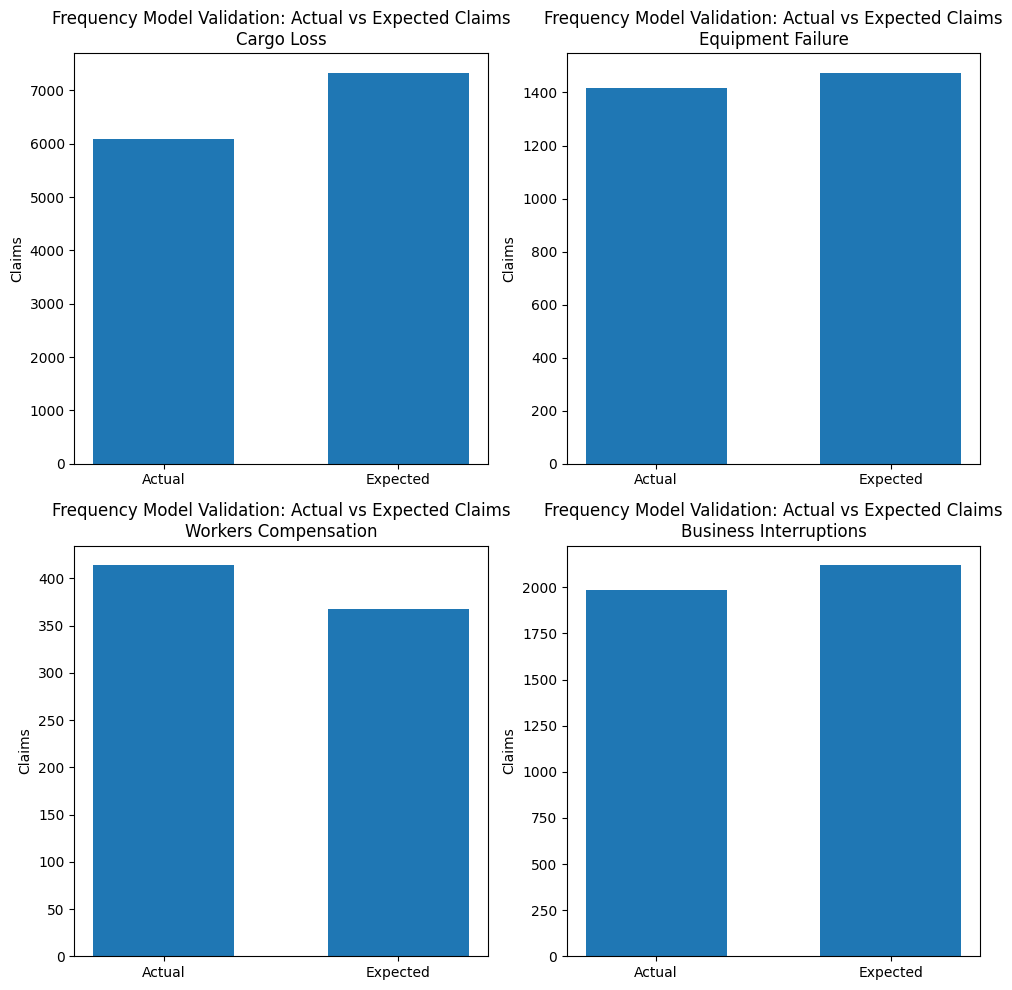

In [310]:
fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, val_df.iterrows()):

    values = [row['Actual'], row['Expected']]
    labels = ['Actual', 'Expected']
    x = np.arange(len(values))

    ax.bar(x, values, width=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    ax.set_ylabel('Claims')
    ax.set_title(f"Frequency Model Validation: Actual vs Expected Claims\n{row['hazard_type']}")

fig.tight_layout()
plt.show()

## Insights

# Severity Models

In [311]:
# Split into training and test data
data_splits = {}

np.random.seed(42)

for name, hazard in hazard_datasets_sev.items():
    # Filter null
    data_clean = hazard.dropna(subset=['claim_amount'])    
    
    # Shuffle and Split (80% Train, 20% Test)
    train_df, test_df = train_test_split(data_clean, test_size=0.20, random_state=42)
    
    data_splits[name] = {
        'train': train_df,
        'test': test_df
    }
severity_models = {}

### Equipment Failure and Business Interruptions - Lognormal Model

In [312]:
for hazard in ['Business Interruption', 'Equipment Failure']: 
    # train data
    train_data = data_splits[hazard]['train']['claim_amount'].values

    # Fit Lognormal Model
    shape, loc, scale = stats.lognorm.fit(train_data, floc=0)

    # store the mdoels
    severity_models[hazard] = {
        'type': 'Lognormal',
        'params': {'shape': shape, 'loc': loc, 'scale': scale},
        'dist_obj': stats.lognorm(s=shape, loc=loc, scale=scale)
    }

### Cargo Loss - Lognormal/Pareto Mode

In [313]:
train_cargo = data_splits['Cargo Loss']['train']['claim_amount'].values

# Threshold for tail
threshold = np.percentile(train_cargo, 95)

# data body
body_data = train_cargo[train_cargo <= threshold]

# Fit Body Lognormal
shape_ln, loc_ln, scale_ln = stats.lognorm.fit(body_data, floc=0)

# Fit Tail Pareto
tail_data = train_cargo[train_cargo > threshold]
shape_p, loc_p, scale_p = stats.pareto.fit(tail_data, floc=0) 

# Add Model to dictionary
severity_models['Cargo Loss'] = {
    'type': 'Spliced Lognormal-Pareto',
    'params': {'body_params': {'shape': shape_ln, 'loc': loc_ln, 'scale': scale_ln},
               'tail_params': {'shape': shape_p, 'loc': loc_p, 'scale': scale_p}},
    'dist': {'body_dist': stats.lognorm(s=shape_ln, loc=loc_ln, scale=scale_ln),
             'tail_dist': stats.pareto(b=shape_p, loc=loc_p, scale=scale_p)}, 
    'threshold': threshold,
}

### Worker Compensation - Gamma/Pareto Model

In [314]:
train_wc = data_splits['Worker Compensation']['train']['claim_amount'].values

# Threshold for tail
threshold = np.percentile(train_wc, 95)

body_data = train_wc[train_wc <= threshold]

# Fit Body Gamma for Worker Compensation only
shape_ln, loc_ln, scale_ln = stats.gamma.fit(body_data, floc=0)

# Fit Tail Pareto
tail_data = train_wc[train_wc > threshold]
shape_p, loc_p, scale_p = stats.pareto.fit(tail_data, floc=0) 

# Add Model to dictionary
severity_models[name] = {

    'type': 'Spliced Gamma-Pareto',
    'params': {'body_params': {'shape': shape_ln, 'loc': loc_ln, 'scale': scale_ln},
               'tail_params': {'shape': shape_p, 'loc': loc_p, 'scale': scale_p}},
    'dist': {'body_dist': stats.gamma(a=shape_ln, loc=loc_ln, scale=scale_ln),
            'tail_dist': stats.pareto(b=shape_p, loc=loc_p, scale=scale_p)}, 
    'threshold': threshold,
}

In [315]:
severity_models

{'Business Interruption': {'type': 'Lognormal',
  'params': {'shape': 1.1954503708885382, 'loc': 0, 'scale': 2126701.63167455},
  'dist_obj': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x30dc23d10>},
 'Equipment Failure': {'type': 'Lognormal',
  'params': {'shape': 0.6032606369127671,
   'loc': 0,
   'scale': 73528.06050673984},
  'dist_obj': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x30dac54d0>},
 'Cargo Loss': {'type': 'Spliced Lognormal-Pareto',
  'params': {'body_params': {'shape': 2.140170445736895,
    'loc': 0,
    'scale': 477751.16343266563},
   'tail_params': {'shape': 1.8377636912563637,
    'loc': 0,
    'scale': 42089072.0}},
  'dist': {'body_dist': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x30ddb0ed0>,
   'tail_dist': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x30bb667d0>},
  'threshold': 42058700.75},
 'Worker Compensation': {'type': 'Spliced Gamma-Pareto',
  'params': {'body_params': {'shape': 0.858264

## Validating Severity Models

In [316]:
val_summary = []

for hazard, model in severity_models.items():
    # Get the actual test data from your data_splits
    test_df = data_splits[hazard]['test']
    actual_mean = test_df['claim_amount'].mean()
    
    # Calculate Expected Mean
    if model['type'] == 'Lognormal':
        # Simple analytic mean for Lognormal
        expected_mean = model['dist_obj'].mean()
    else:
        # Spliced models: Simulate 1M draws to get a robust theoretical mean
        n = 1_000_000
        threshold = model['threshold']
        
        # Calculate the weight of the body
        p_body = model['dist']['body_dist'].cdf(threshold)
        
        # Draw from body and tail
        b_samples = model['dist']['body_dist'].rvs(n)
        t_samples = model['dist']['tail_dist'].rvs(n)
        
        # The spliced mean is the weighted average of the conditional means
        expected_mean = (b_samples[b_samples < threshold].mean() * p_body + 
                         t_samples[t_samples >= threshold].mean() * (1 - p_body))

    # Store results
    val_summary.append({
        'Hazard': hazard,
        'Actual_Mean': round(actual_mean, 2),
        'Expected_Mean': round(expected_mean, 2),
        # Actual data over expected data
        'A/E_Ratio': round(actual_mean / expected_mean, 4),
        'Sample_Size': len(test_df)
    })

severity_val_df = pd.DataFrame(val_summary)

print(severity_val_df)

                  Hazard  Actual_Mean  Expected_Mean  A/E_Ratio  Sample_Size
0  Business Interruption   4444691.10     4345422.73     1.0228         2000
1      Equipment Failure     87308.44       88201.93     0.9899         1649
2             Cargo Loss   7893837.83     3945037.76     2.0010         6089
3    Worker Compensation      7314.58        4085.66     1.7903          383


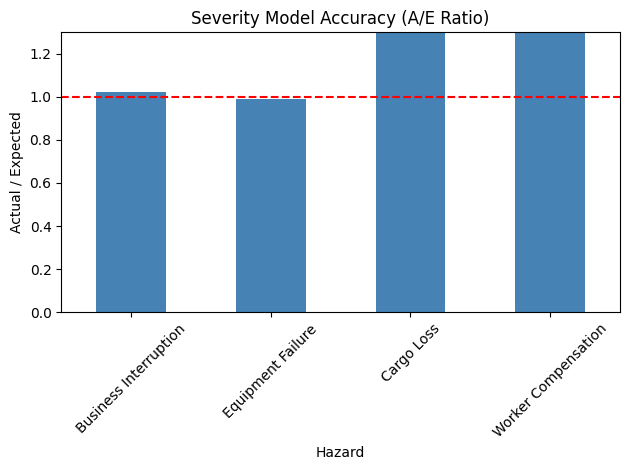

In [317]:
severity_val_df.plot(kind='bar', x='Hazard', y='A/E_Ratio', color='steelblue', legend=False)

# Add a target line at 1.0 (The ideal ratio)
plt.axhline(1.0, color='red', linestyle='--', label='Perfect Calibration')

plt.title('Severity Model Accuracy (A/E Ratio)')
plt.ylabel('Actual / Expected')
plt.ylim(0, 1.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('severity_validation.png')

For A/E ratio, the closer it is to 1 the more accurate the model is.

- Business Interruption and Equipment Failure: they are fully calibrated and ready for use. these risks are stable and the initial parameters are highly accurate.

- Cargo Loss (A/E = 2.00): This model is severely underestimating costs by 100%, likely because it uses a the whole distribution mean that ignores the high value of catastrophes. A single "Total Loss" of high-value cargo pulls the actual mean far above what a simple distribution predicts without considering the shipment's specific attributes.

- Worker Compensation (A/E = 1.79): This model is underestimating costs by 79%, suggesting the "Tail" of the distribution is too thin. In a small sample of 383 claims, a few high-cost medical or disability cases are outweighing the model's expectations, indicating that the Pareto shape parameter needs to be more conservative.

For the "Heavy Hitters" (Cargo and WC), the next step is to lower the Pareto Alpha or adjust the splicing threshold. This mathematically forces the model to expect more frequent and more expensive "Black Swan" events, closing the final gap between the predicted budget and the actual claims.

However, I will be doing the General Linear Model beforehand to discover how and if the combination of risk drivers will incluence the predicted mean and hopefully more accurate

## Severity General Linear Model

In [318]:
severity_hazard_drivers = {
    'Cargo Loss': [
        "C(cargo_type)", "cargo_value", "weight", "route_risk", 
        "transit_duration", "pilot_experience", "vessel_age", 
        "C(container_type)", "solar_radiation","debris_density","exposure"
    ],

    'Equipment Failure': [
        "C(solar_system)", 'equipment_age', 'maintenance_int', 'usage_int',
        'C(equipment_type)'
    ],

    'Worker Compensation': [
        "C(solar_system)", 'C(occupation)', 'C(employment_type)', 'experience_yrs', 
        "accident_history_flag","psych_stress_index" , "hours_per_week", 
        "supervision_level", "gravity_level", "safety_training_index",
        "protective_gear_quality", "base_salary", "exposure"
    ],

    'Business Interruption': [
        "C(solar_system)", 'production_load',
        'exposure', 'energy_backup_score',
        'safety_compliance'
    ]
}

In [319]:
severity_glms = {}

for name, drivers in severity_hazard_drivers.items():
    train_df = data_splits[name]['train'].copy()
    
    # Define the formula (using all your drivers)
    # Note: We use the actual drivers list we defined earlier
    formula = f"claim_amount ~ {' + '.join(drivers)}"
    
    # Fit the Gamma GLM
    # This handles the Body
    model = smf.glm(formula=formula, data=train_df, 
                    family=sm.families.Gamma(link=sm.families.links.log())).fit()
    
    severity_glms[name] = model

/Users/diadana/anaconda3/envs/project_9_215/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/diadana/anaconda3/envs/project_9_215/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/diadana/anaconda3/envs/project_9_215/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/diadana/anaconda3/envs/project_9_215/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0

## Validating General Linear Model

In [320]:
GLM_val = []

for hazard, model in severity_glms.items():
    # Use the test split for this hazard
    test_df = data_splits[hazard]['test'].copy()
    
    # Predict severity for each claim in the test set
    test_df['pred_sev'] = model.predict(test_df)
    
    actual_sum = test_df['claim_amount'].sum()
    pred_sum = test_df['pred_sev'].sum()
    
    GLM_val.append({
        'Hazard': hazard,
        'Test_Actual': actual_sum,
        'Test_Predicted': pred_sum,
        'Test_A/E': actual_sum / pred_sum
    })

GLM_val_df = pd.DataFrame(GLM_val)
print(GLM_val_df)

                  Hazard   Test_Actual  Test_Predicted  Test_A/E
0             Cargo Loss  4.806558e+10    4.565149e+10  1.052881
1      Equipment Failure  1.439716e+08    1.439767e+08  0.999965
2    Worker Compensation  2.801485e+06    3.239209e+06  0.864867
3  Business Interruption  8.889382e+09    8.574997e+09  1.036663


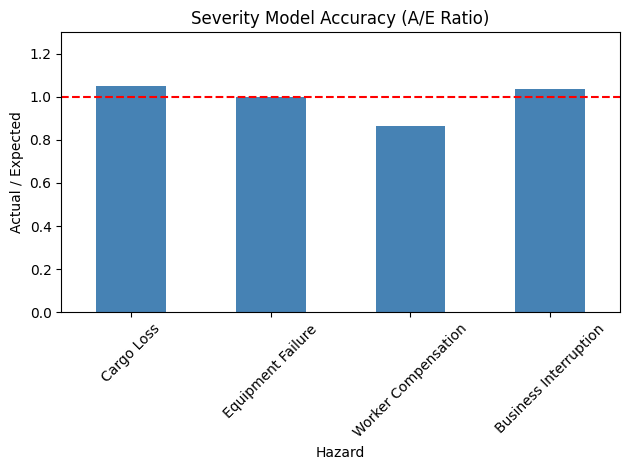

In [321]:
# Create the plot
GLM_val_df.plot(kind='bar', x='Hazard', y='Test_A/E', color='steelblue', legend=False)

# Add a target line at 1.0 (the ideal ratio)
plt.axhline(1.0, color='red', linestyle='--', label='Perfect Calibration')

plt.title('Severity Model Accuracy (A/E Ratio)')
plt.ylabel('Actual / Expected')
plt.ylim(0, 1.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('severity_validation.png')

Previously before applying General Linear Model, the Spliced Lognormal/Pareto model was underestimating Cargo costs by 100% (A/E = 2.0). By introducing drivers like cargo_value and route_risk, the error dropped to just 5% (A/E = 1.05). This confirms that Cargo severity isn't just random; it is heavily dictated by the specific value of the shipment and the danger of the corridor

Both Equipment Failure (A/E = 1.00) and Business Interruption (A/E = 1.04) are nearly perfect. These risks appear to be well-behaved and stable. The GLM provides a sophisticated way to segment these costs without losing the accuracy of the overall mean.

The A/E of 0.86 suggests the Workers Compensation model is slightly conservative, over-predicting actual costs by about 14%. In the context of the 95th-percentile "Body" model you built, this is a safe position. It suggests that while the drivers (like gravity_level or occupation) are strong predictors, the "average" worker injury in your test set was slightly less severe than the historical training average.

Taking risk drivers into consideration solved the underestiamtion for Workers Compensation and Cargo Loss, while also keep Equipment Failure and Business Interruptions stable

# Aggregation Model

**Monte Carlo Simulation** will be the model to aggregate frequency and severity models to extract insights and answer the objectives.

**Monte Carlo Simulation**: used high repeated numbers of random samples to calucate the probability of different outcomes for complex nonlinear systems

How it works here: 
- For each policy, draw a random number of claims from your Frequency Model (Poisson/NB).

- If claims occur, draw a random cost for each from your Severity GLM (Gamma).

- Sum them to get the "Total Loss" for that simulation.

- Repeat 10,000 times to create a Loss Cost Distribution.

In [376]:
# Create a dict for freq prediceted models
freq_lookup = {}

for h in ['Cargo Loss', 'Equipment Failure', 'Workers Compensation', 'Business Interruptions']:
    # Use test_freq because it has all the columns (like supply_chain_index)
    # We predict the rate, not a random draw yet
    df_freq = data_splits_freq[h]['test'].copy()

    df_freq[f'pred_freq_{h}'] = freq_models[h].predict(df_freq)
    
    # Store as a dictionary for fast mapping: {policy_id: predicted_freq}
    freq_lookup[h] = df_freq.set_index('policy_id')[f'pred_freq_{h}'].to_dict()

In [342]:
severity_glms['Business Interruptions'] = severity_glms.pop('Business Interruption')

In [442]:
# create a list of dataframes, one for each hazard, then simulate
scored_hazards = {}

for h in ['Cargo Loss', 'Equipment Failure', 'Workers Compensation', 'Business Interruptions']:
    # Get your severity test data
    df_sev = data_splits[h]['test'].copy()
    
    # Map the frequency prediction using the policy_id
    df_sev['expected_freq'] = df_sev['policy_id'].map(freq_lookup[h])
    
    # Score the Severity using the Severity GLMs (which don't need supply_chain_index)
    df_sev['expected_sev'] = severity_glms[h].predict(df_sev)
    
    scored_hazards[h] = df_sev.fillna(0)

In [443]:
def get_metrics(annual_losses, hazard_name):
    """Calculates all required metrics from a loss distribution.
    Returns: Mean (yearly expected cost)
             Standard Deviation (variance)
             25th - 75th Percentile (50% of the time it will fall within this range)
             Tail risk (the 1 in 100 catastrophies cost)
    """
    var_99 = np.percentile(annual_losses, 99)
    mean = np.mean(annual_losses)
    std = np.std(annual_losses)

    return {
        'Hazard': hazard_name,
        'Mean (Exp. Cost)': mean,
        'Std Dev (Volatility)': std,
        '25th Percentile': np.percentile(annual_losses, 25),
        '75th Percentile': np.percentile(annual_losses, 75),
        '99% VaR (Tail Risk)': var_99,
        '99% TVaR (Tail Mean)': np.mean(annual_losses[annual_losses >= var_99])
    }

def simulate_losses(df, n_sims=10000, shape=1.5):
    """Runs the Monte Carlo simulation for a specific DataFrame."""
    freqs = df['expected_freq'].values
    sevs = df['expected_sev'].values
    annual_losses = np.zeros(n_sims)
    
    for i in range(n_sims):
        num_claims = np.random.poisson(freqs)
        if num_claims.sum() > 0:
            claim_means = np.repeat(sevs, num_claims)
            sim_costs = np.random.gamma(shape=shape, scale=claim_means/shape)
            annual_losses[i] = sim_costs.sum()
    return annual_losses

In [444]:
hazard_list = ['Equipment Failure', 'Workers Compensation', 'Business Interruptions', 'Cargo Loss']
individual_sims = {}
individual_metrics = []

for h in hazard_list:
    # Run simulation
    losses = simulate_losses(scored_hazards[h])
    individual_sims[h] = losses 
    
    # Calculate Metrics
    metrics = get_metrics(losses, h)
    individual_metrics.append(metrics)

# Create Table
df_aggre_metrics = pd.DataFrame(individual_metrics)

In [445]:
# Add a Total Portfolio

# Sum all individual simulations row-by-row
portfolio_losses = np.sum([individual_sims[h] for h in hazard_list], axis=0)

# Calculate Metrics for the Total Portfolio
portfolio_metrics = get_metrics(portfolio_losses, "Total Portfolio")

# Create Final Summary Table
df_aggre_metrics = pd.concat([df_aggre_metrics, pd.DataFrame([portfolio_metrics])], ignore_index=True)

df_aggre_metrics

,Hazard,Mean (Exp. Cost),Std Dev (Volatility),25th Percentile,75th Percentile,99% VaR (Tail Risk),99% TVaR (Tail Mean)
0,Equipment Failure,5.498572e+06,9.496208e+05,4.837548e+06,6.122674e+06,7.861634e+06,8.280877e+06
1,Workers Compensation,8.906550e+04,4.458454e+04,5.772446e+04,1.124328e+05,2.254735e+05,2.696369e+05
2,Business Interruptions,3.552946e+08,5.020135e+07,3.209106e+08,3.880002e+08,4.782880e+08,4.975583e+08
3,Cargo Loss,5.233659e+09,5.819273e+08,4.835930e+09,5.619890e+09,6.697330e+09,6.897924e+09
4,Total Portfolio,5.594542e+09,5.840748e+08,5.196512e+09,5.979028e+09,7.067747e+09,7.260368e+09


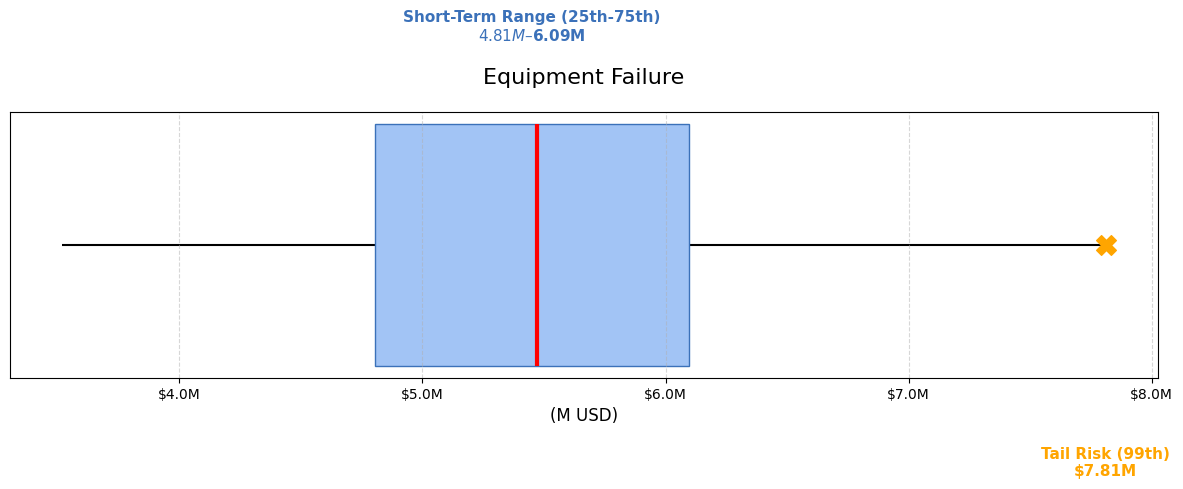

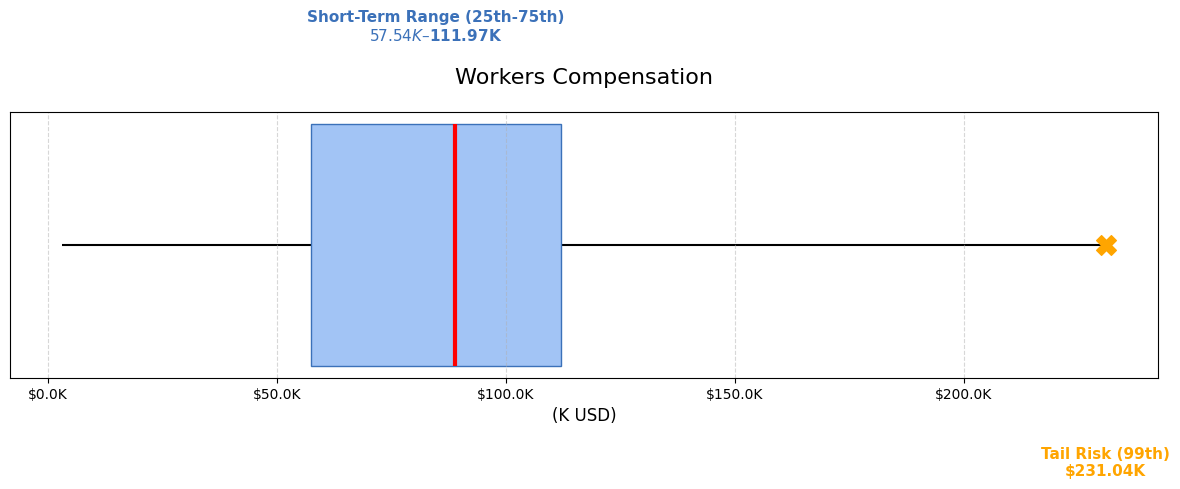

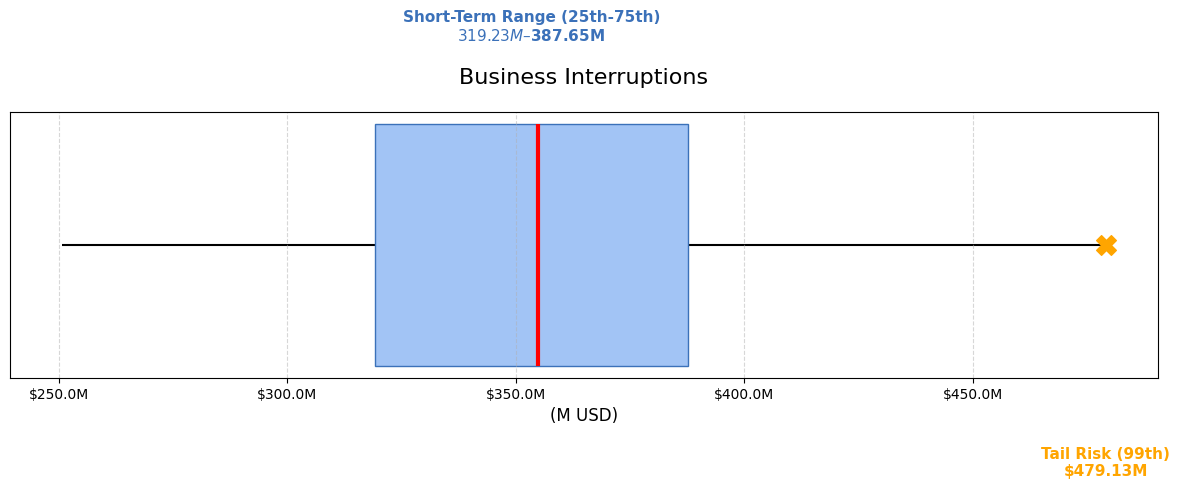

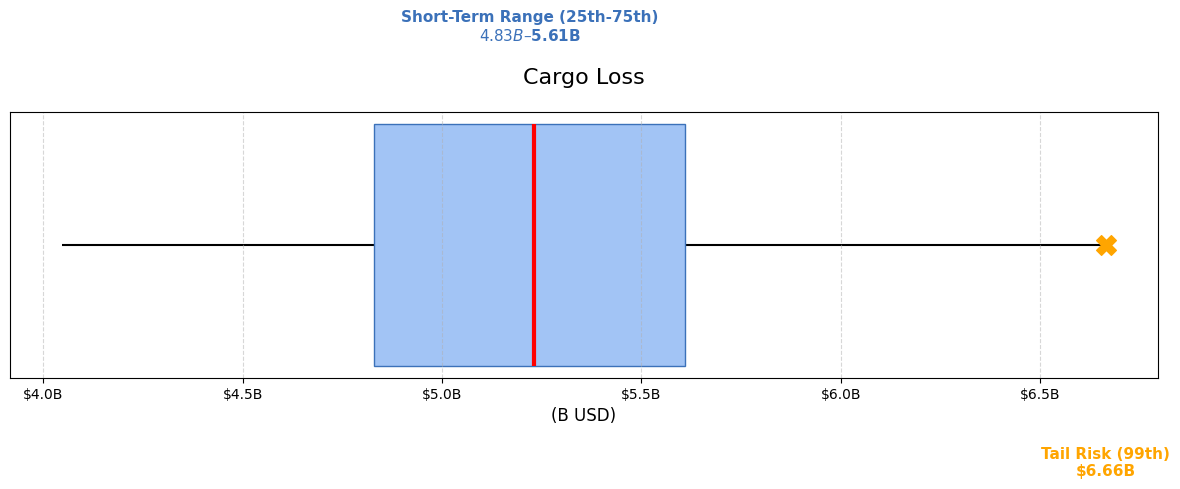

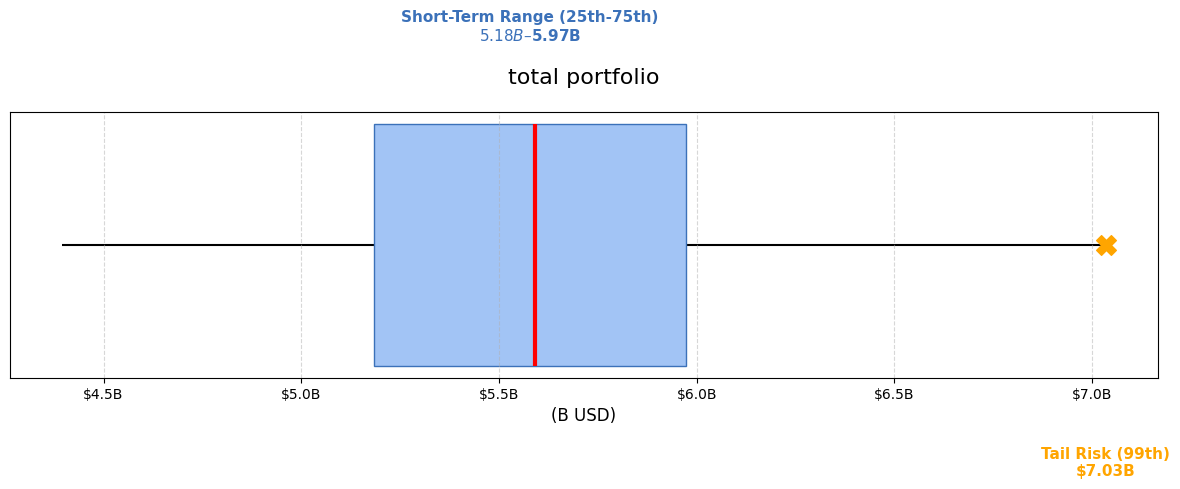

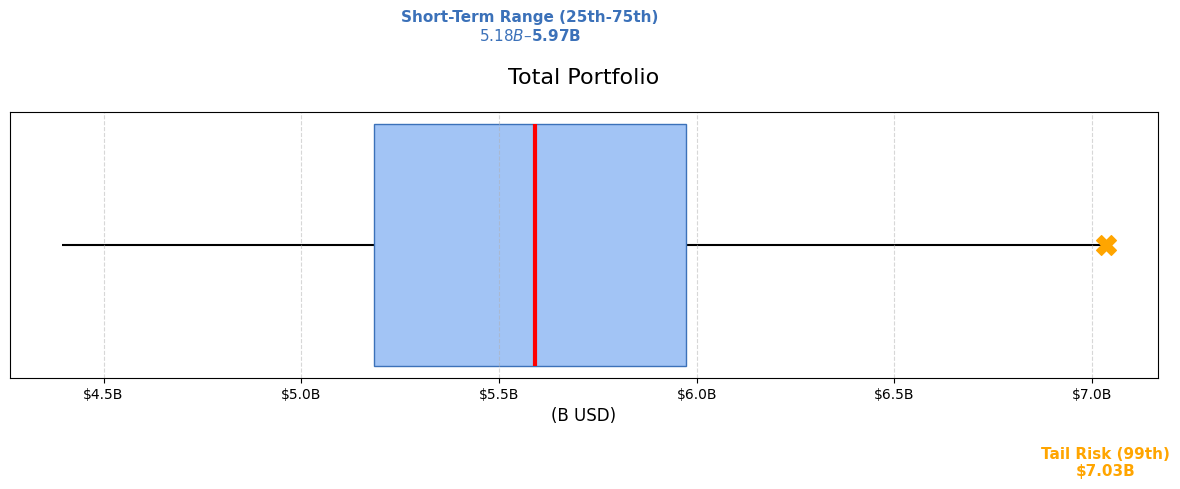

In [ ]:
def plot_actuarial_range_from_metrics(row):
    hazard = row['Hazard']
    mean = row['Mean (Exp. Cost)']
    p25 = row['25th Percentile']
    p75 = row['75th Percentile']
    p99 = row['99% VaR (Tail Risk)']
    
    # Auto-adjust scale (B for Portfolio/Cargo, M/K for others)
    scale, unit = (1e9, "B") if mean >= 1e9 else (1e6, "M") if mean >= 1e6 else (1e3, "K")
    
    plt.figure(figsize=(12, 6))
    
    # Draw the Range Box (25th to 75th)
    plt.barh(1, (p75 - p25), left=p25, height=0.3, color='#A2C4F5', edgecolor='#3B71B9')
    
    # Draw the Mean Line (Red)
    plt.vlines(mean, 0.85, 1.15, color='red', linewidth=3)
    
    # draw the Whisker Line and Tail Risk 'X'
    left_whisker = p25 - (p75 - p25) # Aesthetics to match your screenshot
    plt.hlines(1, left_whisker, p99, colors='black', linewidth=1.5, zorder=0)
    plt.scatter(p99, 1, color='orange', marker='X', s=200, zorder=5)
    
    # Text Annotations: Short-Term Range & Tail Risk
    plt.text((p25 + p75)/2, 1.25, f"Short-Term Range (25th-75th)\n${p25/scale:.2f}{unit} – ${p75/scale:.2f}{unit}", 
             ha='center', va='bottom', color='#3B71B9', fontweight='bold', fontsize=11)
    
    plt.text(p99, 0.75, f"Tail Risk (99th)\n${p99/scale:.2f}{unit}", 
             ha='center', va='top', color='orange', fontweight='bold', fontsize=11)
    
    # Formatting
    plt.title(f'{hazard}', fontsize=16, pad=20)
    plt.xlabel(f'({unit} USD)', fontsize=12)
    plt.yticks([])
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/scale:.1f}{unit}'))
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"aggre_range{hazard.replace(' ', '_')}.png")

# --- Applying to your Data ---
# This assumes your summary table is named 'df_metrics'
for _, row in df_aggre_metrics.iterrows():
    plot_actuarial_range_from_metrics(row)

# Further Insights

### Claim Count rate per hazard

,Avg_Claim_Rate
Cargo Loss,0.127381
Equipment Failure,0.038333
Workers Compensation,0.026969
Business Interruptions,0.041481


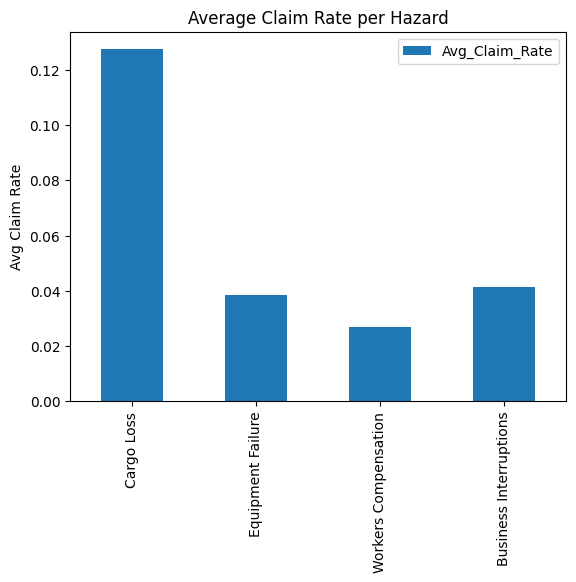

In [432]:
hazard_rates = {}

for h, df in scored_hazards.items():
    # The mean of expected_freq is the average claim rate (λ)
    hazard_rates[h] = df['expected_freq'].mean()

# Convert to a readable DataFrame
hazard_rate_df = pd.DataFrame.from_dict(hazard_rates, orient='index', columns=['Avg_Claim_Rate'])

hazard_rate_df.plot.bar()
plt.title('Average Claim Rate per Hazard')
plt.ylabel('Avg Claim Rate')

hazard_rate_df

### Claim Count per solar system

,solar_system,expected_freq,hazard
1,Epsilon,0.036842,Equipment Failure
2,Helionis Cluster,0.046847,Equipment Failure
3,Zeta,0.032935,Equipment Failure
1,Epsilon,0.024371,Workers Compensation
2,Helionis Cluster,0.028401,Workers Compensation
3,Zeta,0.028591,Workers Compensation
1,Epsilon,0.043745,Business Interruptions
2,Helionis Cluster,0.032598,Business Interruptions
3,Zeta,0.043585,Business Interruptions


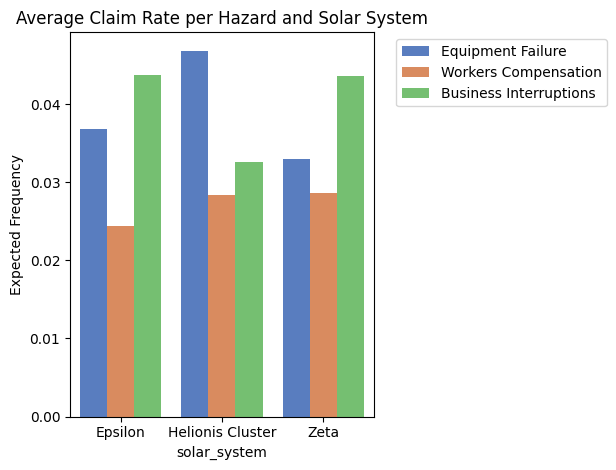

In [447]:
system_rates = []

for h, df in scored_hazards.items():    
    # There is no solar_system column in Carog Loss
    if h == 'Cargo Loss':
        continue

    # Group by solar system and find the average predicted frequency
    rate_by_system = df.groupby('solar_system')['expected_freq'].mean().reset_index()
    rate_by_system['hazard'] = h
    system_rates.append(rate_by_system)

# Combine into one table
master_system_rates = pd.concat(system_rates)
master_system_rates = master_system_rates[master_system_rates['solar_system'].astype(str) != '0'].copy()


# Pivot for a clean "Heatmap" style view
system_pivot = master_system_rates.pivot(index='solar_system', columns='hazard', values='expected_freq')


sns.heatmap(system_pivot, annot=True, cmap='RdYlGn_r', fmt='.4f')
plt.title('Average Claim Rate per Hazard and Solar System')
plt.tight_layout()
plt.savefig('risk_heatmap.png')
plt.clf()

sns.barplot(data=master_system_rates, x='solar_system', y='expected_freq', hue='hazard', palette='muted')
plt.title('Average Claim Rate per Hazard and Solar System')
plt.ylabel('Expected Frequency')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('risk_barplot.png')

master_system_rates


### Significant and influcential Drivers for claims amount and count

In [ ]:
def get_significant_drivers_df(models_dict):
    """
    Analyzes GLM frequency models and returns a DataFrame of 
    statistically significant drivers and their percentage impact.
    """
    all_results = []
    
    for hazard, model in models_dict.items():
        # Create a DF for model's results
        df = pd.DataFrame({
            'hazard': hazard,
            'variable': model.params.index,
            'coefficient': model.params.values,
            'p_value': model.pvalues.values
        })
        
        # 2. Filter for Significance (p < 0.05) and exclude Intercept
        df = df[(df['p_value'] < 0.05) & (df['variable'] != 'Intercept')].copy()
        
        # Calculate Percentage Impact: (exp(coef) - 1) * 100
        # This translates the log-link coefficient to a 'Rate'
        df['pct_impact'] = (np.exp(df['coefficient']) - 1) * 100
        
        # dd a Direction label
        df['impact_direction'] = df['pct_impact'].apply(lambda x: 'Increase' if x > 0 else 'Decrease')
        
        all_results.append(df)
    
    # Combine everything into one master table
    master_driver_df = pd.concat(all_results, ignore_index=True)
    
    # Sort by absolute impact to show the most powerful drivers at the top
    master_driver_df['abs_impact'] = master_driver_df['pct_impact'].abs()
    return master_driver_df.sort_values(by=['hazard', 'abs_impact'], ascending=[True, False])

# Execute and store
freq_sig_drivers_df = get_significant_drivers_df(freq_models)
sev_sig_drivers_df = get_significant_drivers_df(severity_glms)

In [449]:
freq_sig_drivers_df

,hazard,variable,coefficient,p_value,pct_impact,impact_direction,abs_impact
26,Business Interruptions,energy_backup_score,0.022521,3.138277e-02,2.277638,Increase,2.277638
27,Business Interruptions,maintenance_freq,-0.018996,1.007234e-02,-1.881717,Decrease,1.881717
5,Cargo Loss,solar_radiation,0.156763,3.687681e-02,16.971786,Increase,16.971786
0,Cargo Loss,C(container_type)[T.HardSeal Transit Crate],0.094720,5.218711e-05,9.935091,Increase,9.935091
1,Cargo Loss,C(container_type)[T.QuantumCrate Module],0.081878,4.830104e-04,8.532365,Increase,8.532365
2,Cargo Loss,route_risk,0.049810,8.235471e-12,5.107101,Increase,5.107101
3,Cargo Loss,pilot_experience,-0.004556,2.032007e-03,-0.454564,Decrease,0.454564
4,Cargo Loss,vessel_age,-0.001865,1.384427e-02,-0.186347,Decrease,0.186347
12,Equipment Failure,C(equipment_type)[T.ReglAggregators],-0.708652,1.126907e-36,-50.769247,Decrease,50.769247
11,Equipment Failure,C(equipment_type)[T.Quantum Bore],-0.626870,2.539812e-28,-46.573877,Decrease,46.573877


In [400]:
sev_sig_drivers_df

,hazard,variable,coefficient,p_value,pct_impact,impact_direction,abs_impact
0,Cargo Loss,C(cargo_type)[T.gold],4.066073e+00,0.000000e+00,5.732748e+03,Increase,5.732748e+03
2,Cargo Loss,C(cargo_type)[T.platinum],3.571254e+00,0.000000e+00,3.456117e+03,Increase,3.456117e+03
4,Cargo Loss,C(cargo_type)[T.titanium],-2.059808e+00,0.000000e+00,-8.725216e+01,Decrease,8.725216e+01
3,Cargo Loss,C(cargo_type)[T.supplies],-1.797419e+00,0.000000e+00,-8.342739e+01,Decrease,8.342739e+01
8,Cargo Loss,solar_radiation,4.777814e-01,1.411006e-14,6.124929e+01,Increase,6.124929e+01
1,Cargo Loss,C(cargo_type)[T.lithium],4.462148e-01,1.257417e-69,5.623871e+01,Increase,5.623871e+01
9,Cargo Loss,debris_density,3.191401e-01,3.107115e-07,3.759441e+01,Increase,3.759441e+01
7,Cargo Loss,route_risk,1.759844e-01,7.653677e-183,1.924195e+01,Increase,1.924195e+01
10,Cargo Loss,exposure,5.377717e-02,3.218301e-02,5.524944e+00,Increase,5.524944e+00
6,Cargo Loss,weight,7.423845e-06,9.862212e-188,7.423872e-04,Increase,7.423872e-04


### Drivers indicating high catastrophy potential

In [439]:
high_severity_drivers = sev_sig_drivers_df.sort_values(by='pct_impact', ascending=False)

print(high_severity_drivers[['variable', 'pct_impact']].head(20))

                                   variable    pct_impact
0                     C(cargo_type)[T.gold]  5.732748e+03
2                 C(cargo_type)[T.platinum]  3.456117e+03
16        C(equipment_type)[T.Quantum Bore]  1.503772e+02
20      C(solar_system)[T.Helionis Cluster]  7.681177e+01
15      C(equipment_type)[T.Ion Pulverizer]  6.327215e+01
17     C(equipment_type)[T.ReglAggregators]  6.168890e+01
8                           solar_radiation  6.124929e+01
1                  C(cargo_type)[T.lithium]  5.623871e+01
14  C(equipment_type)[T.Graviton Extractor]  4.414151e+01
9                            debris_density  3.759441e+01
21                       psych_stress_index  1.963916e+01
7                                route_risk  1.924195e+01
12                  C(solar_system)[T.Zeta]  1.642010e+01
13          C(equipment_type)[T.Flux Rider]  1.191433e+01
10                                 exposure  5.524944e+00
18                            equipment_age  3.193488e+00
19            